<a href="https://colab.research.google.com/github/esther033/2026-1_CV/blob/main/hw3/02_experiment_B_activation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 실험 B — 활성화 함수 비교: ReLU vs LeakyReLU vs Sigmoid

## 실험 목표
- ReLU, LeakyReLU, Sigmoid가 학습에 미치는 영향 분석
- **Dead ReLU** 발생을 의도적으로 유도하고, LeakyReLU의 완화 효과 확인
- **Sigmoid의 vanishing gradient** 시각화
- Layer별 activation 분포 변화 (학습 초/중/후반) 시각화

## 실험 조건
| 항목 | 값 |
|---|---|
| 데이터셋 | `make_moons`, `make_circles` (2D, 비선형 경계) |
| 네트워크 | MLP: `2 → 64 → 64 → 64 → 2` (의도적으로 깊게) |
| 손실함수 | CrossEntropy |
| 옵티마이저 | Adam, lr=0.01 |
| Epoch | 300 |
| **가중치 초기화** | `std=0.01` (Dead ReLU 유도용 — 과제 명시 조건) |
| 시드 | 42 |


## 0. 셋업

In [1]:

from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/CV_hw#3')

from common_utils import (
    set_seed, get_device, fit,
    plot_loss_acc_curves, plot_gradient_flow,
    register_activation_hooks, plot_activation_distribution,
    compute_dead_ratio, plot_dead_neuron_heatmap,
    summarize_histories
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

set_seed(42)
device = get_device()
print("Device:", device)


Mounted at /content/drive
Device: cuda


## 1. 2D 데이터셋 (make_moons, make_circles)

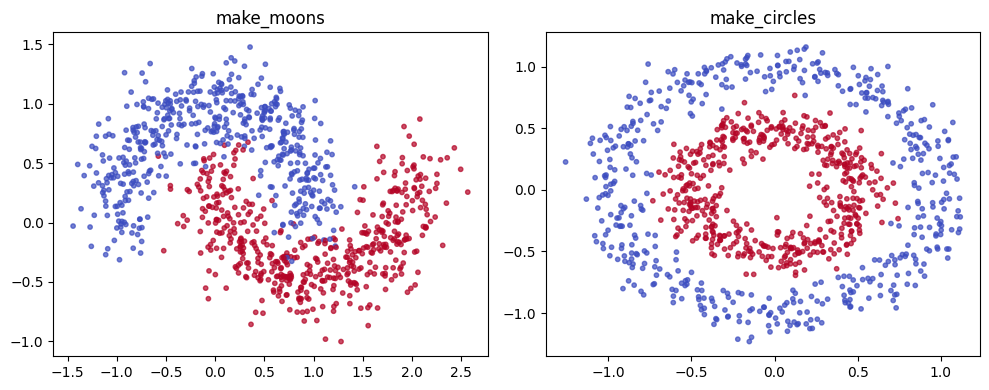

In [2]:
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split

def make_loader_2d(X, y, batch_size=64):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    tr = DataLoader(
        TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                      torch.tensor(y_tr, dtype=torch.long)),
        batch_size=batch_size, shuffle=True
    )
    te = DataLoader(
        TensorDataset(torch.tensor(X_te, dtype=torch.float32),
                      torch.tensor(y_te, dtype=torch.long)),
        batch_size=batch_size
    )
    return (X_tr, y_tr, X_te, y_te), tr, te

X_m, y_m = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_c, y_c = make_circles(n_samples=1000, noise=0.1, factor=0.5, random_state=42)

(Xm_tr, ym_tr, Xm_te, ym_te), moons_tr, moons_te = make_loader_2d(X_m, y_m)
(Xc_tr, yc_tr, Xc_te, yc_te), circles_tr, circles_te = make_loader_2d(X_c, y_c)

# 데이터 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X_m[:, 0], X_m[:, 1], c=y_m, cmap='coolwarm', s=10, alpha=0.7)
axes[0].set_title('make_moons')
axes[1].scatter(X_c[:, 0], X_c[:, 1], c=y_c, cmap='coolwarm', s=10, alpha=0.7)
axes[1].set_title('make_circles')
plt.tight_layout(); plt.show()


## 2. 모델 정의 (Dead ReLU 유도용 초기화 포함)

> **Dead ReLU 유도 조건** (과제 명시):
> - 가중치 초기값을 `std=0.01`로 매우 작게 설정.
> - 작은 weight + 음수 bias로 인해 ReLU 입력이 거의 음수 → 출력 0이 고착.


In [3]:
def make_mlp_2d(activation: nn.Module, hidden_sizes=(64, 64, 64),
                small_init=True):
    """
    2D 분류용 MLP. 입력 2차원 → 은닉층들 → 출력 2차원(클래스 수).

    Args:
        activation: 활성화 함수 인스턴스 (nn.ReLU(), nn.LeakyReLU(0.1), nn.Sigmoid())
        hidden_sizes: 은닉층 뉴런 개수
        small_init: True면 weight std=0.01로 초기화 (Dead ReLU 유도)
    """
    layers = []
    prev = 2
    for h in hidden_sizes:
        lin = nn.Linear(prev, h)
        if small_init:
            # 매우 작은 표준편차로 초기화 + 약간 음수 bias (Dead ReLU 유도)
            nn.init.normal_(lin.weight, mean=0.0, std=0.01)
            nn.init.constant_(lin.bias,  -0.1)
        layers.extend([lin, activation.__class__(**_act_kwargs(activation))])
        prev = h
    layers.append(nn.Linear(prev, 2))  # 출력층 (2 클래스)
    return nn.Sequential(*layers)


def _act_kwargs(act_instance):
    """활성화 함수 인스턴스에서 생성 인자를 추출 (LeakyReLU의 negative_slope 등)."""
    if isinstance(act_instance, nn.LeakyReLU):
        return {'negative_slope': act_instance.negative_slope}
    return {}


## 3. 학습 (make_moons)

In [4]:
EPOCHS_B = 300
LR_B = 0.01

activations_test = {
    'ReLU':      nn.ReLU(),
    'LeakyReLU': nn.LeakyReLU(0.1),
    'Sigmoid':   nn.Sigmoid(),
}

histories_moons = {}
models_moons = {}

for name, act in activations_test.items():
    set_seed(42)
    model = make_mlp_2d(act, small_init=True).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR_B)
    print(f"\n>>> make_moons + {name}")
    histories_moons[name] = fit(
        model, moons_tr, moons_te,
        nn.CrossEntropyLoss(), opt, device,
        epochs=EPOCHS_B, log_every=50
    )
    models_moons[name] = model



>>> make_moons + ReLU
[  1/300] train_loss=0.6939 train_acc=50.00% test_loss=0.6933 test_acc=50.00% grad_norm=0.1139 lr=0.01000
[ 50/300] train_loss=0.6932 train_acc=50.00% test_loss=0.6931 test_acc=50.00% grad_norm=0.1004 lr=0.01000
[100/300] train_loss=0.6935 train_acc=50.00% test_loss=0.6932 test_acc=50.00% grad_norm=0.0842 lr=0.01000
[150/300] train_loss=0.6932 train_acc=50.25% test_loss=0.6932 test_acc=50.00% grad_norm=0.0614 lr=0.01000
[200/300] train_loss=0.6935 train_acc=48.25% test_loss=0.6932 test_acc=50.00% grad_norm=0.0721 lr=0.01000
[250/300] train_loss=0.6935 train_acc=47.00% test_loss=0.6932 test_acc=50.00% grad_norm=0.0934 lr=0.01000
[300/300] train_loss=0.6933 train_acc=47.00% test_loss=0.6932 test_acc=50.00% grad_norm=0.0620 lr=0.01000

>>> make_moons + LeakyReLU
[  1/300] train_loss=0.6903 train_acc=50.75% test_loss=0.5699 test_acc=80.00% grad_norm=0.1459 lr=0.01000
[ 50/300] train_loss=0.0675 train_acc=97.38% test_loss=0.0341 test_acc=98.50% grad_norm=0.6653 lr=0.0

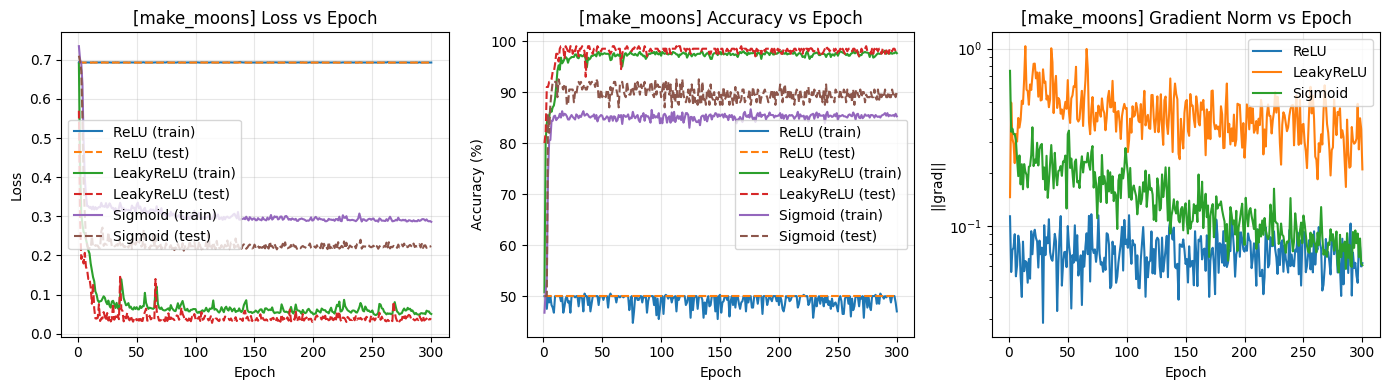

In [5]:
plot_loss_acc_curves(histories_moons, title_prefix='[make_moons]')


## 4. 결정경계 시각화 (2D만 가능한 장점)

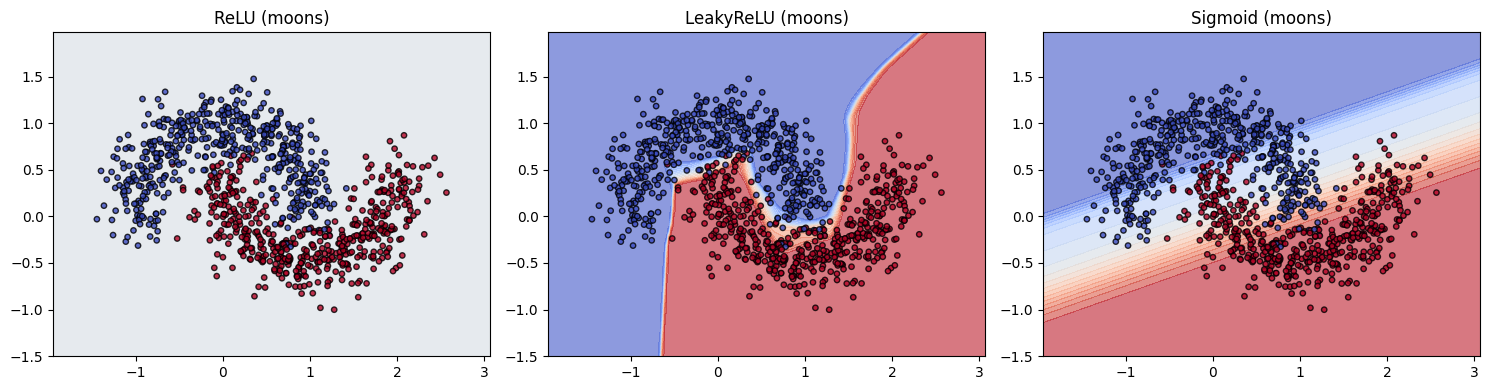

In [6]:
def plot_decision_boundary(models: dict, X, y, title_suffix=""):
    """여러 모델의 결정경계를 한 그림에 비교."""
    n = len(models)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]

    # 격자 생성
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                          np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]

    for ax, (name, model) in zip(axes, models.items()):
        model.eval()
        with torch.no_grad():
            logits = model(torch.tensor(grid, dtype=torch.float32).to(device))
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        ax.contourf(xx, yy, probs.reshape(xx.shape), levels=20,
                    cmap='coolwarm', alpha=0.6)
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm',
                    edgecolors='k', s=15, alpha=0.8)
        ax.set_title(f"{name} {title_suffix}")
    plt.tight_layout(); plt.show()

plot_decision_boundary(models_moons, X_m, y_m, title_suffix="(moons)")


## 5. Activation 분포 시각화 (학습 초/중/후)

각 활성화 함수에 forward hook을 걸어 레이어별 출력값 분포를 확인.


ReLU activations (after training)


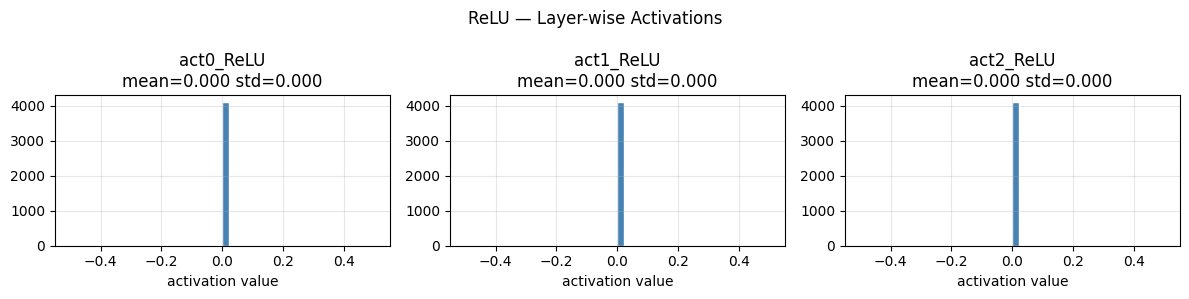

LeakyReLU activations (after training)


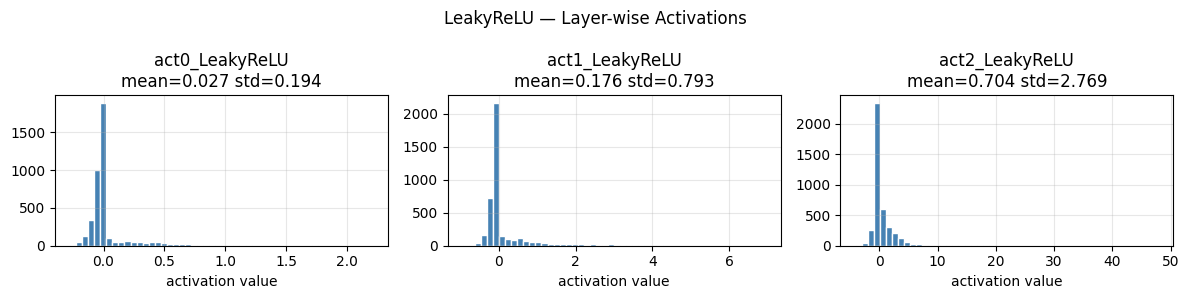

Sigmoid activations (after training)


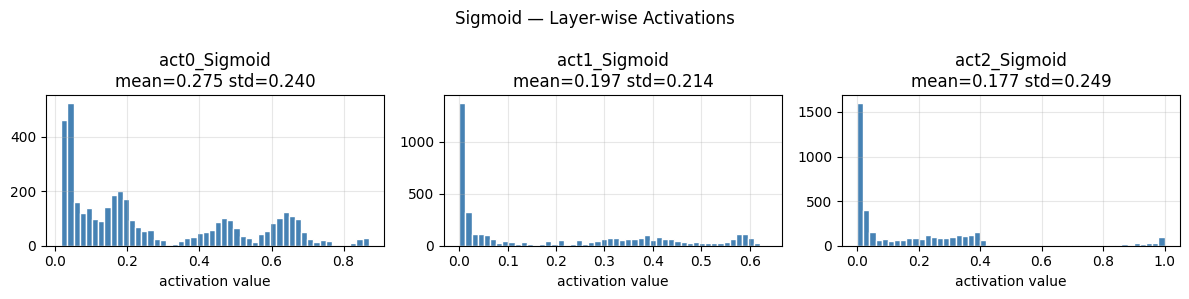

In [7]:
def capture_activations_at_stage(model, loader, label):
    """모델에 hook을 걸고 1배치 forward → activation 캡처."""
    activations, hooks = register_activation_hooks(model)
    model.eval()
    with torch.no_grad():
        xb, _ = next(iter(loader))
        _ = model(xb.to(device))
    plot_activation_distribution(
        activations, title=f"{label} — Layer-wise Activations"
    )
    info = compute_dead_ratio(activations)
    for h in hooks: h.remove()
    return info

# 학습이 끝난 시점에서의 activation
print("=" * 60); print("ReLU activations (after training)"); print("=" * 60)
info_relu = capture_activations_at_stage(models_moons['ReLU'], moons_te, 'ReLU')

print("=" * 60); print("LeakyReLU activations (after training)"); print("=" * 60)
info_leaky = capture_activations_at_stage(models_moons['LeakyReLU'], moons_te, 'LeakyReLU')

print("=" * 60); print("Sigmoid activations (after training)"); print("=" * 60)
info_sig = capture_activations_at_stage(models_moons['Sigmoid'], moons_te, 'Sigmoid')


**관찰 포인트**
- ReLU: dead 뉴런 비율이 높을 가능성 (값이 0에 몰림).
- LeakyReLU: 음수 부분에도 작은 신호가 있어 분포가 더 넓게 분산.
- Sigmoid: 출력이 0 또는 1로 극단 saturation → vanishing gradient의 원인.


## 6. Dead ReLU 비율 — 히트맵 시각화

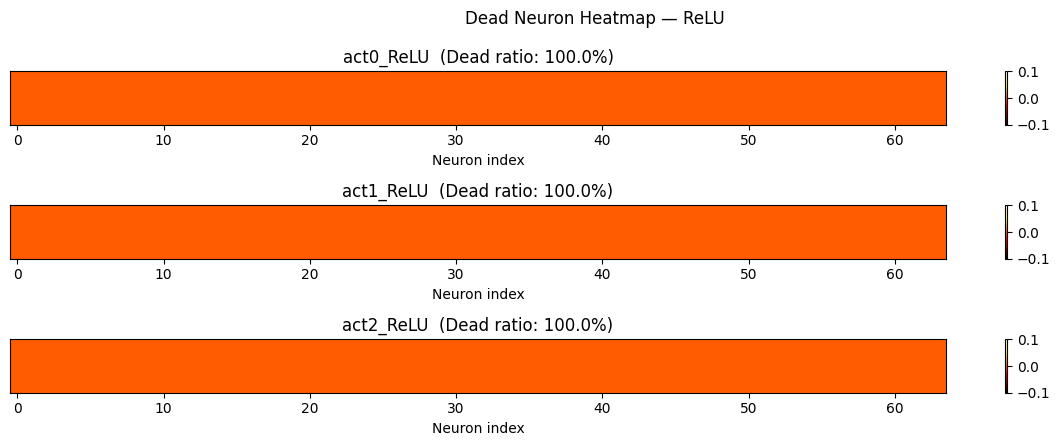

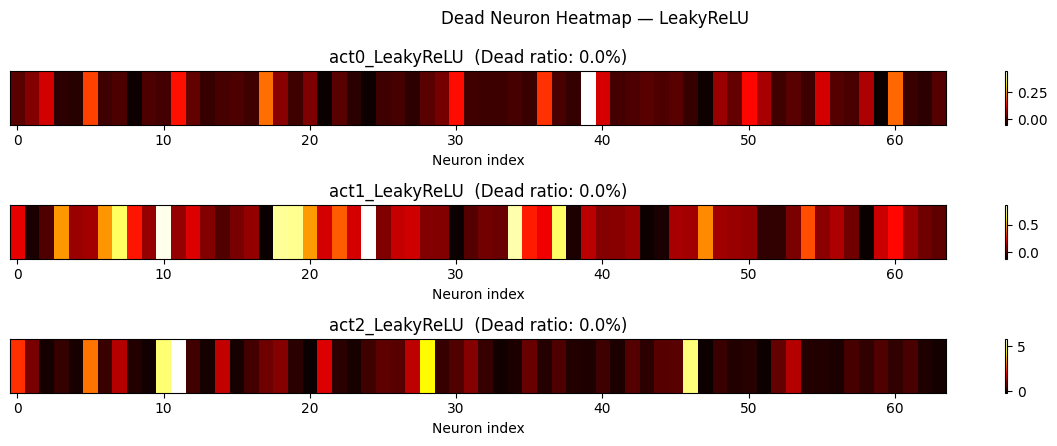

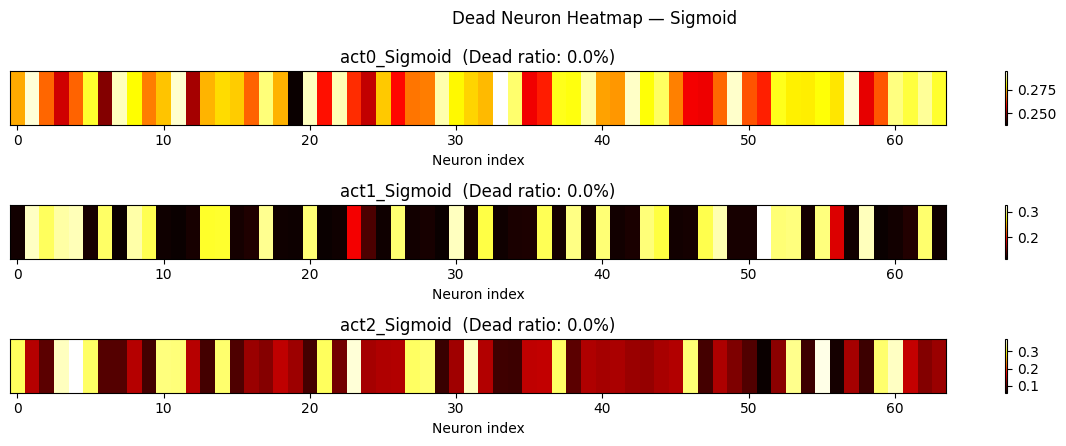

In [8]:
# 한 번의 forward로 캡처한 activation을 히트맵으로
for name, model in models_moons.items():
    activations, hooks = register_activation_hooks(model)
    model.eval()
    with torch.no_grad():
        xb, _ = next(iter(moons_te))
        _ = model(xb.to(device))
    plot_dead_neuron_heatmap(activations,
                             title=f"Dead Neuron Heatmap — {name}")
    for h in hooks: h.remove()


In [9]:
# Dead ratio 요약 표
import pandas as pd

def dead_ratio_summary(model_dict, loader):
    rows = []
    for name, model in model_dict.items():
        activations, hooks = register_activation_hooks(model)
        model.eval()
        with torch.no_grad():
            xb, _ = next(iter(loader))
            _ = model(xb.to(device))
        info = compute_dead_ratio(activations)
        for layer_name, d in info.items():
            rows.append({
                'activation': name,
                'layer': layer_name,
                'dead_ratio(%)': round(d['ratio'] * 100, 2),
            })
        for h in hooks: h.remove()
    return pd.DataFrame(rows)

dead_df = dead_ratio_summary(models_moons, moons_te)
dead_df


,activation,layer,dead_ratio(%)
0,ReLU,act0_ReLU,100.0
1,ReLU,act1_ReLU,100.0
2,ReLU,act2_ReLU,100.0
3,LeakyReLU,act0_LeakyReLU,0.0
4,LeakyReLU,act1_LeakyReLU,0.0
5,LeakyReLU,act2_LeakyReLU,0.0
6,Sigmoid,act0_Sigmoid,0.0
7,Sigmoid,act1_Sigmoid,0.0
8,Sigmoid,act2_Sigmoid,0.0


## 7. Gradient Flow 시각화 (vanishing 확인)

/content/drive/MyDrive/Colab Notebooks/CV_hw#3/common_utils.py:423: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')  # log scale로 vanishing 잘 보이게
/content/drive/MyDrive/Colab Notebooks/CV_hw#3/common_utils.py:427: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/drive/MyDrive/Colab Notebooks/CV_hw#3/common_utils.py:427: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/drive/MyDrive/Colab Notebooks/CV_hw#3/common_utils.py:427: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning

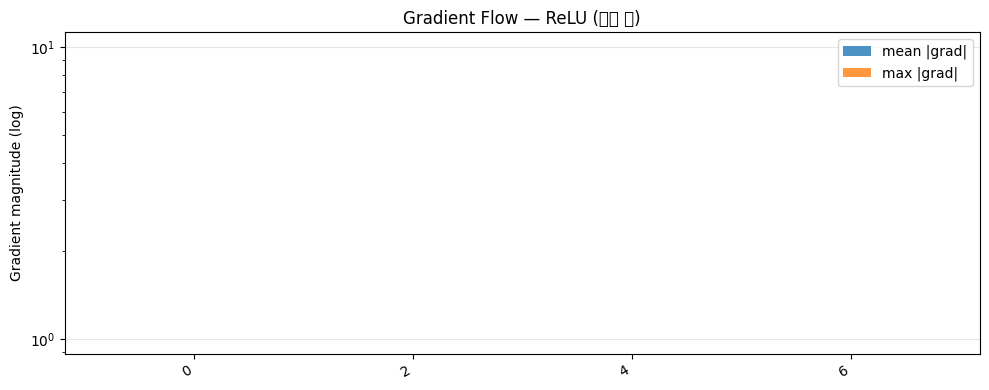

/content/drive/MyDrive/Colab Notebooks/CV_hw#3/common_utils.py:427: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/drive/MyDrive/Colab Notebooks/CV_hw#3/common_utils.py:427: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/drive/MyDrive/Colab Notebooks/CV_hw#3/common_utils.py:427: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWar

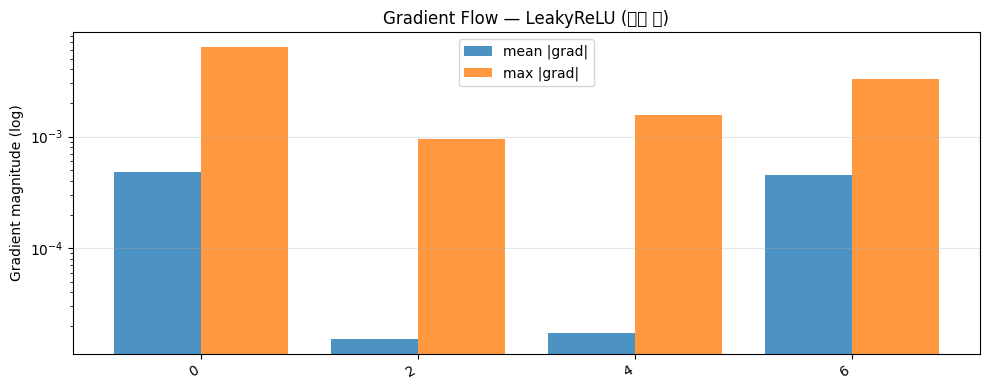

/content/drive/MyDrive/Colab Notebooks/CV_hw#3/common_utils.py:427: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/drive/MyDrive/Colab Notebooks/CV_hw#3/common_utils.py:427: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/drive/MyDrive/Colab Notebooks/CV_hw#3/common_utils.py:427: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWar

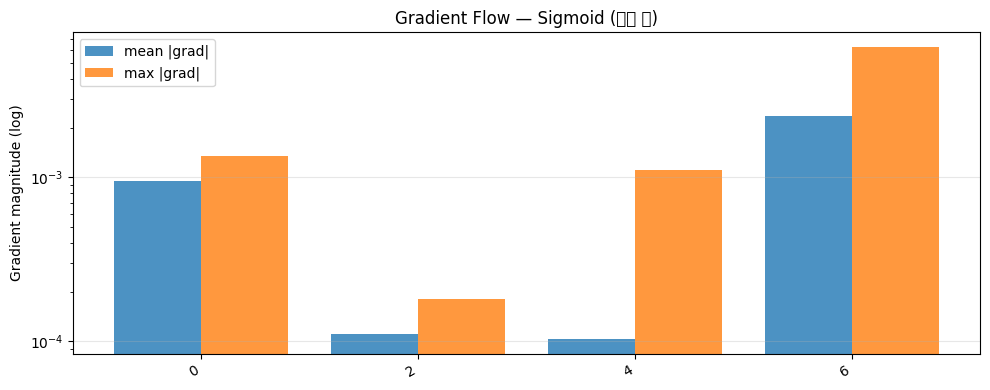

In [10]:
def snapshot_grad_flow_2d(model, loader):
    model.train()
    xb, yb = next(iter(loader))
    xb, yb = xb.to(device), yb.to(device)
    logits = model(xb)
    loss = nn.CrossEntropyLoss()(logits, yb)
    model.zero_grad()
    loss.backward()

for name, model in models_moons.items():
    snapshot_grad_flow_2d(model, moons_tr)
    plot_gradient_flow(model, title=f'Gradient Flow — {name} (학습 후)')


**해설 가이드**
- Sigmoid는 첫 번째 레이어로 갈수록 gradient가 0에 가까워지는 패턴이 보일 것 (vanishing).
- ReLU는 입력이 음수인 뉴런에서 gradient가 0 → dead neuron 누적.
- LeakyReLU는 음수 영역에도 작은 기울기가 있어 모든 레이어에 신호가 흐름.


## 8. make_circles 추가 실험 (재현성 확인)

>>> make_circles + ReLU
[  1/300] train_loss=0.6939 train_acc=50.00% test_loss=0.6933 test_acc=50.00% grad_norm=0.1139 lr=0.01000
[100/300] train_loss=0.6935 train_acc=50.00% test_loss=0.6932 test_acc=50.00% grad_norm=0.0842 lr=0.01000
[200/300] train_loss=0.6935 train_acc=48.25% test_loss=0.6932 test_acc=50.00% grad_norm=0.0721 lr=0.01000
[300/300] train_loss=0.6933 train_acc=47.00% test_loss=0.6932 test_acc=50.00% grad_norm=0.0620 lr=0.01000
>>> make_circles + LeakyReLU
[  1/300] train_loss=0.6941 train_acc=50.00% test_loss=0.6932 test_acc=50.00% grad_norm=0.1159 lr=0.01000
[100/300] train_loss=0.0047 train_acc=99.88% test_loss=0.0414 test_acc=98.50% grad_norm=0.1893 lr=0.01000
[200/300] train_loss=0.0117 train_acc=99.38% test_loss=0.0847 test_acc=98.00% grad_norm=0.4860 lr=0.01000
[300/300] train_loss=0.0107 train_acc=99.62% test_loss=0.0433 test_acc=98.50% grad_norm=0.3718 lr=0.01000
>>> make_circles + Sigmoid
[  1/300] train_loss=0.7352 train_acc=46.75% test_loss=0.7115 test_acc=5

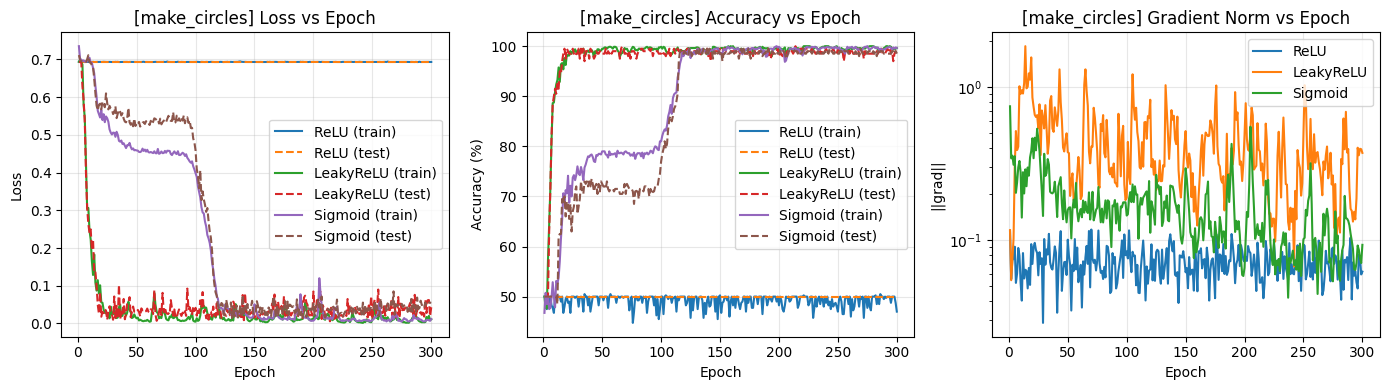

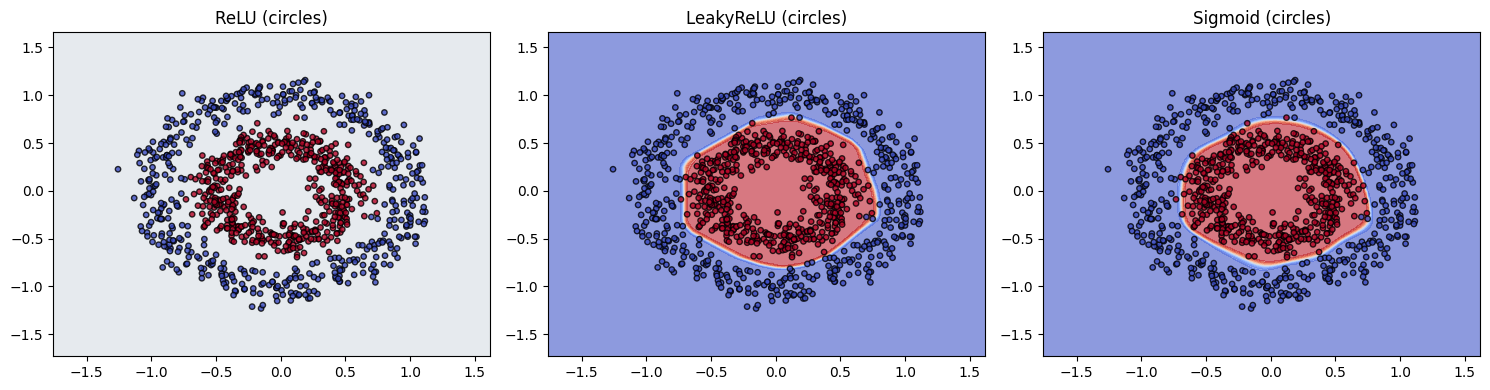

In [11]:
histories_circles = {}
models_circles = {}

for name, act in activations_test.items():
    set_seed(42)
    model = make_mlp_2d(act, small_init=True).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR_B)
    print(f">>> make_circles + {name}")
    histories_circles[name] = fit(
        model, circles_tr, circles_te,
        nn.CrossEntropyLoss(), opt, device,
        epochs=EPOCHS_B, log_every=100
    )
    models_circles[name] = model

plot_loss_acc_curves(histories_circles, title_prefix='[make_circles]')
plot_decision_boundary(models_circles, X_c, y_c, title_suffix='(circles)')


## 9. 정량 비교표 (실험 B)

In [12]:
summary_b = []
for ds_name, hist_dict in [('moons', histories_moons),
                          ('circles', histories_circles)]:
    for act_name, h in hist_dict.items():
        summary_b.append({
            'dataset': ds_name,
            'activation': act_name,
            'final_test_acc(%)': round(h['test_acc'][-1], 2),
            'best_test_acc(%)':  round(max(h['test_acc']), 2),
            'min_train_loss':    round(min(h['train_loss']), 4),
            # 수렴 epoch: train_loss가 (min*1.05) 이하로 처음 도달한 시점
            'convergence_epoch': next(
                (i + 1 for i, v in enumerate(h['train_loss'])
                  if v <= min(h['train_loss']) * 1.05),
                len(h['train_loss'])
            ),
        })
summary_b_df = pd.DataFrame(summary_b)
summary_b_df.to_csv('results_B_activation.csv', index=False)
summary_b_df


,dataset,activation,final_test_acc(%),best_test_acc(%),min_train_loss,convergence_epoch
0,moons,ReLU,50.0,50.0,0.6931,1
1,moons,LeakyReLU,98.0,99.0,0.0473,200
2,moons,Sigmoid,90.0,92.5,0.2859,75
3,circles,ReLU,50.0,50.0,0.6931,1
4,circles,LeakyReLU,98.5,100.0,0.0015,242
5,circles,Sigmoid,98.5,99.5,0.0046,275


In [13]:
# (검증 실험) He 초기화 → Dead ReLU 완화 효과
def make_mlp_2d_he(activation, hidden_sizes=(64, 64, 64)):
    layers = []
    prev = 2
    for h in hidden_sizes:
        lin = nn.Linear(prev, h)
        nn.init.kaiming_normal_(lin.weight, nonlinearity='relu')  # He init
        nn.init.constant_(lin.bias, 0.0)
        layers.extend([lin, activation.__class__()])
        prev = h
    layers.append(nn.Linear(prev, 2))
    return nn.Sequential(*layers)

set_seed(42)
model_he = make_mlp_2d_he(nn.ReLU()).to(device)
opt = torch.optim.Adam(model_he.parameters(), lr=LR_B)
hist_he = fit(model_he, moons_tr, moons_te,
              nn.CrossEntropyLoss(), opt, device,
              epochs=EPOCHS_B, log_every=100)

# Dead ratio 비교
acts_he, hooks = register_activation_hooks(model_he)
model_he.eval()
with torch.no_grad():
    xb, _ = next(iter(moons_te))
    _ = model_he(xb.to(device))
info_he = compute_dead_ratio(acts_he)
for h in hooks: h.remove()

print("Dead ratio 비교 (ReLU, make_moons):")
print(f"  small_init (std=0.01) : {[(k, round(v['ratio']*100, 1)) for k, v in info_relu.items()]}")
print(f"  He init               : {[(k, round(v['ratio']*100, 1)) for k, v in info_he.items()]}")
print(f"  최종 정확도: small_init={histories_moons['ReLU']['test_acc'][-1]:.2f}%, "
      f"He init={hist_he['test_acc'][-1]:.2f}%")


[  1/300] train_loss=0.4173 train_acc=79.38% test_loss=0.2237 test_acc=90.50% grad_norm=1.1126 lr=0.01000
[100/300] train_loss=0.0565 train_acc=97.25% test_loss=0.0415 test_acc=98.50% grad_norm=0.2258 lr=0.01000
[200/300] train_loss=0.0399 train_acc=98.00% test_loss=0.0273 test_acc=99.00% grad_norm=0.2229 lr=0.01000
[300/300] train_loss=0.0380 train_acc=98.75% test_loss=0.0536 test_acc=98.00% grad_norm=0.3489 lr=0.01000
Dead ratio 비교 (ReLU, make_moons):
  small_init (std=0.01) : [('act0_ReLU', 100.0), ('act1_ReLU', 100.0), ('act2_ReLU', 100.0)]
  He init               : [('act0_ReLU', 1.6), ('act1_ReLU', 39.1), ('act2_ReLU', 25.0)]
  최종 정확도: small_init=50.00%, He init=98.00%
